# Inventory impact value ceiling

`frozen_grid_inventory_impact.ipynb` names the right objective — expected PLP profit per dollar of economic capital — and then calibrates against a revenue target instead of measuring that objective. It reports what one reference transition would be charged. It never reports whether charging changes the ratio.

This notebook asks the prior question:

> How much can *any* concentration-pricing mechanism improve PLP risk-adjusted return, at the best case, before we choose a coordinate or a rate?

The answer is a ceiling, not a forecast. If the ceiling is small, no coordinate and no calibration can rescue the mechanism. If it is large, the next question — which is not this notebook's — is how much of it a cheap coordinate captures.

## Objective

For pool income `F` and economic capital `K`,

```text
R = F / K,    K = E[payout | worst 5% of outcomes] - E[payout]
```

`F` counts **every** income component. The frozen-grid notebook excludes base-fee and spread income from its numerator so pricing compensation cannot excuse tail risk. That guardrail is right for sizing one fee in isolation and wrong for measuring risk-adjusted return, because the ratio is a property of the whole book: raising one fee line by 22% while leaving `K` untouched barely moves `R`.

## Why the denominator is not the frozen grid

`K` is computed from the true settlement distribution over 2,000 equal-probability cells, never from the 100-bucket grid. Using `K95_grid` as the denominator would be circular — the diversification counterfactual minimizes exactly what the denominator measures, so any improvement would be an artifact of the estimator instead of a fact about the pool. Here `K95_grid` is visibly one coarse, conservative *estimator* of the quantity below, which is what makes a later coordinate comparison meaningful rather than tautological.

## No volatility assumption enters

A range contract pays a fixed amount on a probability interval, so working in probability space rather than price space makes every quantity here invariant to the shape of the pricing measure. No lognormal, SVI, smile, or volatility assumption is used, and no objection of the form "your surface is wrong" can reach the conclusion.

## Three channels, separated

| Channel | Effect | Requires |
| --- | --- | --- |
| Revenue | raises `F`, leaves `K` | nothing — flow trades anyway |
| Composition | leaves `F`, lowers `K` | trader elasticity, unobservable pre-launch |
| Refusal | lowers `K`, forgoes income | an admission rule, achievable deterministically |

Relocation preserves each trade's probability width and quantity, so its premium and fee are unchanged and composition affects only the denominator.

## Decision rule, registered before the run

Let `improvement` be the combined ceiling's gain in `R` over baseline at central clustering.

- **under 15%** — stop; the mechanism cannot pay for its complexity.
- **15% to 50%** — build the coordinate comparison; shipping depends on how much a cheap coordinate captures.
- **50% or more** — the mechanism is worth having; the remaining question is which estimator is cheapest.

Secondary: if revenue alone is more than 80% of the achievable improvement, a flat base-fee increase is the simpler substitute. If refusal alone reaches 90% of the combined ceiling, prefer an admission cap over a fee, because a cap needs no calibration and cannot be out-run by an edge larger than the rate.

## Non-claims

This is a ceiling, not a prediction. Relocation is a counterfactual about the pool, not a claim that a trader would accept a different product. The refusal frontier is greedy in arrival order, so it is an achievable policy rather than a global optimum. Nothing here calibrates `B_K` or `r_K`, measures frozen-grid staleness, or addresses adverse selection.

In [1]:
"""Part 1 — objective and model primitives."""

from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# The settlement line is 2,000 equal-probability cells, chosen so the worst 5%
# is an integer number of cells and no interpolation is needed anywhere.
CELLS = 2_000
TAIL_CELLS = CELLS // 20
assert TAIL_CELLS * 20 == CELLS

# strike_exposure_config::raw_bernoulli_fee_rate charges
# base_fee * sqrt(p(1-p)) * quantity, scaled by the near-expiry ramp. Fee
# income varies with a range's probability, so it changes which trades are
# attractive per dollar of capital. The ramp scales all income equally and
# therefore cancels out of every ratio reported below.
BASE_FEE_RATE = 0.02
FEE_RAMP = 1.0

# The frozen-grid notebook's Part 5 recommendation, used only for the
# revenue-channel measurement.
B_K = 1_000.0
R_K = 0.02


@dataclass(frozen=True)
class Trade:
    """One range position sold by the pool, in settlement-cell coordinates."""

    lower: int
    upper: int
    quantity: float

    @property
    def mass(self) -> float:
        return (self.upper - self.lower) / CELLS

    @property
    def fee(self) -> float:
        m = self.mass
        return BASE_FEE_RATE * float(np.sqrt(m * (1.0 - m))) * FEE_RAMP * self.quantity


def payout_profile(trades) -> np.ndarray:
    """Payout the pool owes in each settlement cell."""
    edges = np.zeros(CELLS + 1)
    for trade in trades:
        edges[trade.lower] += trade.quantity
        edges[trade.upper] -= trade.quantity
    return np.cumsum(edges[:-1])


def economic_capital(payout: np.ndarray) -> float:
    """Centered 95% expected shortfall of pool payout.

    Income is identical in every settlement cell, so it cancels out of the
    difference: capital is a property of the payout book alone. This is the
    exact quantity K95_grid estimates, evaluated at cell resolution with true
    means instead of conservative bucket maxima.
    """
    cut = CELLS - TAIL_CELLS
    tail = np.partition(payout, cut)[cut:]
    return float(tail.mean() - payout.mean())


def batch_capital(payouts: np.ndarray) -> np.ndarray:
    """`economic_capital` over rows of candidate payout books."""
    cut = CELLS - TAIL_CELLS
    tail = np.partition(payouts, cut, axis=1)[:, cut:]
    return tail.mean(axis=1) - payouts.mean(axis=1)


def potential(capital: float) -> float:
    """Capped convex potential Phi[r_K, B_K] from the frozen-grid design."""
    if capital <= 0.0:
        return 0.0
    if capital <= B_K:
        return R_K * capital * capital / (2.0 * B_K)
    return R_K * B_K / 2.0 + R_K * (capital - B_K)


# Parity against Part 1 of frozen_grid_inventory_impact.ipynb. Agreeing on
# these establishes that both notebooks measure the same quantity before they
# disagree about anything.
_parity = [
    ("guaranteed full-line payout", [Trade(0, CELLS, 1_000.0)], 0.0),
    ("five-bucket pile-on, 5% mass", [Trade(0, CELLS // 20, 1_000.0)], 950.0),
    ("ten-bucket plateau, 10% mass", [Trade(0, CELLS // 10, 900.0)], 810.0),
]
parity = pd.DataFrame(
    [
        {
            "scenario": name,
            "this notebook K ($)": economic_capital(payout_profile(book)),
            "frozen-grid notebook ΔK ($)": expected,
        }
        for name, book, expected in _parity
    ]
)
for _, row in parity.iterrows():
    assert abs(row["this notebook K ($)"] - row["frozen-grid notebook ΔK ($)"]) < 1e-9

print(f"{CELLS} settlement cells, worst-5% tail = {TAIL_CELLS} cells")
print("Frozen-grid notebook parity passed on all three reference books.")
parity.style.format({"this notebook K ($)": "${:,.2f}", "frozen-grid notebook ΔK ($)": "${:,.2f}"}).hide(axis="index")

2000 settlement cells, worst-5% tail = 100 cells
Frozen-grid notebook parity passed on all three reference books.


scenario,this notebook K ($),frozen-grid notebook ΔK ($)
guaranteed full-line payout,$0.00,$0.00
"five-bucket pile-on, 5% mass",$950.00,$950.00
"ten-bucket plateau, 10% mass",$810.00,$810.00


# Part 2 — flow and baseline

There is no production flow to replay, so flow is generated and the generating assumption is the main threat to validity. It is exposed as one parameter rather than buried.

**Clustering** is the probability that a trade's range is drawn near a shared per-market theme location instead of independently across the line. At `0`, flow is naturally diversified and no concentration mechanism can help by construction. At `1`, every trader piles into the same region. The headline result is the ceiling *as a function of clustering*, and the central case is deliberately in the middle.

Everything else is held at plausible values and stated explicitly: six range widths from 0.5% to 20% of probability mass, a lognormal quantity with a $1,000 median, and 200 trades per market. `R` scales linearly with the fee ramp, so the ramp cancels from every improvement ratio and its value does not affect the decision.

In [2]:
"""Part 2 — flow generation and the one simulation engine."""

WIDTH_MASSES = np.array([0.005, 0.01, 0.02, 0.05, 0.10, 0.20])
THEME_SPREAD_CELLS = 40  # clustered trades land within roughly 2% of the line
MEDIAN_QUANTITY = 1_000.0
QUANTITY_LOG_SD = 0.8
TRADES_PER_MARKET = 200
CENTRAL_CLUSTERING = 0.5
SEEDS = 16
CANDIDATE_STRIDE = 25  # relocation search grid over the settlement line


def draw_flow(n_trades: int, clustering: float, rng: np.random.Generator) -> list[Trade]:
    theme = int(rng.integers(0, CELLS))
    trades = []
    for _ in range(n_trades):
        width = int(round(float(rng.choice(WIDTH_MASSES)) * CELLS))
        if rng.random() < clustering:
            center = int(round(rng.normal(theme, THEME_SPREAD_CELLS)))
        else:
            center = int(rng.integers(0, CELLS))
        lower = int(np.clip(center - width // 2, 0, CELLS - width))
        quantity = float(MEDIAN_QUANTITY * np.exp(rng.normal(0.0, QUANTITY_LOG_SD)))
        trades.append(Trade(lower, lower + width, quantity))
    return trades


def simulate(trades, *, steer: float = 0.0, hurdle: float | None = None,
             charge: bool = False, seed: int = 0) -> dict:
    """Walk flow in arrival order under one policy and return book outcomes.

    `steer` is the fraction of trades that relocate to the position minimizing
    resulting capital, preserving width and quantity so the fee is unchanged.
    `hurdle` refuses a trade whose fee falls below `hurdle` dollars per dollar
    of marginal capital. `charge` accrues the non-refundable potential increase
    as income.
    """
    payout = np.zeros(CELLS)
    capital = 0.0
    fee_income = 0.0
    inventory_income = 0.0
    accepted = 0
    volume = 0.0
    steer_rng = np.random.default_rng(90_000 + seed)

    for trade in trades:
        width = trade.upper - trade.lower
        if steer > 0.0 and steer_rng.random() < steer:
            starts = np.arange(0, CELLS - width + 1, CANDIDATE_STRIDE)
            candidates = np.tile(payout, (starts.size, 1))
            for index, start in enumerate(starts):
                candidates[index, start:start + width] += trade.quantity
            capitals = batch_capital(candidates)
            best = int(np.argmin(capitals))
            lower = int(starts[best])
            capital_after = float(capitals[best])
        else:
            lower = trade.lower
            trial = payout.copy()
            trial[lower:lower + width] += trade.quantity
            capital_after = economic_capital(trial)

        marginal = capital_after - capital
        if hurdle is not None and marginal > 0.0 and trade.fee < hurdle * marginal:
            continue

        if charge:
            inventory_income += max(0.0, potential(capital_after) - potential(capital))
        payout[lower:lower + width] += trade.quantity
        capital = capital_after
        fee_income += trade.fee
        accepted += 1
        volume += trade.quantity

    income = fee_income + inventory_income
    return {
        "income ($)": income,
        "inventory income ($)": inventory_income,
        "K ($)": capital,
        "R": income / capital if capital > 0.0 else float("nan"),
        "accepted": accepted,
        "volume ($)": volume,
    }


baseline = pd.DataFrame(
    simulate(draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING, np.random.default_rng(seed)),
             seed=seed)
    for seed in range(SEEDS)
)

# How concentrated is the capital? Walk one market and record marginal capital
# per trade so the reader can see whether a few trades create most of K.
walk_rng = np.random.default_rng(0)
walk_flow = draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING, walk_rng)
walk_payout = np.zeros(CELLS)
walk_capital = 0.0
marginals = []
for trade in walk_flow:
    walk_payout[trade.lower:trade.upper] += trade.quantity
    after = economic_capital(walk_payout)
    marginals.append(after - walk_capital)
    walk_capital = after
marginals = np.array(marginals)
positive = marginals[marginals > 0.0]
share_top_decile = float(np.sort(positive)[-len(positive) // 10:].sum() / marginals.sum())

print(f"clustering = {CENTRAL_CLUSTERING}, {TRADES_PER_MARKET} trades, {SEEDS} seeds")
print(f"baseline income  ${baseline['income ($)'].mean():,.2f}")
print(f"baseline K       ${baseline['K ($)'].mean():,.2f}")
print(f"baseline R       {baseline['R'].mean():.4f}  (income per dollar of capital)")
print(f"{len(positive)} of {TRADES_PER_MARKET} trades raise capital; "
      f"the largest decile of those creates {share_top_decile:.0%} of it")
baseline.describe().loc[["mean", "std", "min", "max"]].style.format("{:,.4f}")

clustering = 0.5, 200 trades, 16 seeds
baseline income  $1,104.97
baseline K       $64,793.29
baseline R       0.0173  (income per dollar of capital)
109 of 200 trades raise capital; the largest decile of those creates 42% of it


,income ($),inventory income ($),K ($),R,accepted,volume ($)
mean,"1,104.9750",0.0000,"64,793.2918",0.0173,200.0000,"266,124.6355"
std,79.6295,0.0000,"9,619.7257",0.0022,0.0000,"20,255.7150"
min,945.0832,0.0000,"46,616.7841",0.0151,200.0000,"225,409.7284"
max,"1,194.0968",0.0000,"79,013.0427",0.0233,200.0000,"307,803.9234"


# Part 3 — the three channels, and why the prize must be stated as capital

**The pre-registered metric turned out to be the wrong one, and the reason matters.** Improvement in `R` is unbounded under full relocation. With 200 trades averaging 6.4% of probability mass, the book carries roughly thirteen line-covers of payout, so a perfect allocator can tile it almost flat and drive `K` toward zero. Any ratio with `K` in the denominator then explodes, and a number like "+2,000%" reports the degeneracy of the counterfactual rather than a fact about the pool. The original rule is still evaluated below for the record, but the decision is taken on bounded quantities instead.

The bounded restatement of the prize is **capital removed**:

```text
capital removed = 1 - K_policy / K_baseline
```

This lives in `[0, 1]`, and at full relocation it answers a genuinely useful question: what fraction of the capital PLPs hold is created by *where* flow landed rather than by how much of it there was? That fraction is the total prize any concentration mechanism competes for.

Rows below, all on the same flow, paired seed by seed:

- **baseline** — flow as drawn, base fee only.
- **revenue only** — the non-refundable charge `max(0, ΔΦ)` at the notebook's recommended `B_K` and `r_K`, accrued with no behavioral response. Fully achievable, numerator only.
- **full relocation** — every trade moved to the capital-minimizing position at the same width and quantity, so fees are unchanged and only `K` moves. Not achievable; it sizes the prize.
- **refusal, unconstrained** — trades refused below a hurdle per dollar of marginal capital, swept for the best `R`. Achievable with an admission cap and no elasticity assumption, but it may keep very little volume.
- **refusal, keep ≥50% volume** — the same sweep restricted to policies that retain at least half the flow, which is the version that resembles a shippable cap.
- **combined** — full relocation plus the volume-constrained hurdle.

In [3]:
"""Part 3 — measure each channel, bound the prize, and size the aggregate charge."""

HURDLES = np.concatenate([[0.0], np.geomspace(1e-4, 1.0, 13)])
MIN_VOLUME_KEPT = 0.50


def channels(trades, seed: int) -> tuple[dict[str, dict], float]:
    """Run every policy on one flow; return outcomes and the shippable hurdle."""
    base = simulate(trades, seed=seed)
    result = {
        "baseline": base,
        "revenue only": simulate(trades, charge=True, seed=seed),
        "full relocation": simulate(trades, steer=1.0, seed=seed),
    }

    frontier = [(h, simulate(trades, hurdle=h, seed=seed)) for h in HURDLES]
    viable = [(h, out) for h, out in frontier if np.isfinite(out["R"])]
    _, unconstrained = max(viable, key=lambda pair: pair[1]["R"])
    retained = [
        (h, out) for h, out in viable
        if out["volume ($)"] >= MIN_VOLUME_KEPT * base["volume ($)"]
    ]
    shippable_hurdle, shippable = max(retained, key=lambda pair: pair[1]["R"])

    result["refusal, unconstrained"] = unconstrained
    result["refusal, keep >=50% volume"] = shippable
    result["combined"] = simulate(trades, steer=1.0, hurdle=shippable_hurdle, seed=seed)
    return result, shippable_hurdle


per_seed: dict[str, list[dict]] = {}
shippable_hurdles = []
for seed in range(SEEDS):
    flow = draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING, np.random.default_rng(seed))
    outcomes, hurdle = channels(flow, seed)
    shippable_hurdles.append(hurdle)
    for name, outcome in outcomes.items():
        per_seed.setdefault(name, []).append(outcome)

# Paired per-seed ratios, then averaged: averaging R across seeds first would
# let one low-capital seed dominate every comparison.
base_frame = pd.DataFrame(per_seed["baseline"])
rows = []
for name, outcomes in per_seed.items():
    frame = pd.DataFrame(outcomes)
    ratio = frame["R"].to_numpy() / base_frame["R"].to_numpy()
    rows.append({
        "policy": name,
        "income ($)": frame["income ($)"].mean(),
        "K ($)": frame["K ($)"].mean(),
        "R": frame["R"].mean(),
        "capital removed": 1.0 - (frame["K ($)"] / base_frame["K ($)"]).mean(),
        "volume kept": (frame["volume ($)"] / base_frame["volume ($)"]).mean(),
        "R gain": ratio.mean() - 1.0,
    })
summary = pd.DataFrame(rows)


def field(policy: str, column: str) -> float:
    return float(summary.loc[summary["policy"] == policy, column].iloc[0])


prize = field("full relocation", "capital removed")
refusal_capital = field("refusal, keep >=50% volume", "capital removed")
refusal_volume = field("refusal, keep >=50% volume", "volume kept")
combined_r_gain = field("combined", "R gain")
revenue_r_gain = field("revenue only", "R gain")
refusal_r_gain = field("refusal, keep >=50% volume", "R gain")

# How large is the charge in aggregate, against the notebook's single-trade figure?
inventory_income = float(pd.DataFrame(per_seed["revenue only"])["inventory income ($)"].mean())
base_fee_income = float(base_frame["income ($)"].mean())

print(f"median shippable hurdle: {np.median(shippable_hurdles):.4g} $ of fee per $ of "
      f"marginal capital")
print()
print(f"PRIZE  {prize:.1%} of baseline capital is created by where flow landed, not by "
      f"how much of it there was.")
print(f"       Baseline K ${base_frame['K ($)'].mean():,.0f} -> "
      f"${field('full relocation', 'K ($)'):,.0f} under perfect allocation.")
print()
print(f"ACHIEVABLE WITHOUT ELASTICITY")
print(f"       refusal keeping {refusal_volume:.0%} of volume removes "
      f"{refusal_capital:.1%} of capital, "
      f"which is {refusal_capital / prize:.0%} of the prize.")
print()
print(f"AGGREGATE CHARGE SIZE at B_K=${B_K:,.0f}, r_K={R_K:.0%}")
print(f"       inventory income ${inventory_income:,.0f} vs base-fee income "
      f"${base_fee_income:,.0f} = {inventory_income / base_fee_income:.0%} of base fees.")
print(f"       The frozen-grid notebook reports 22.6% for one $950 transition from an empty "
      f"book; on a 200-trade book the cumulative charge is far larger because K accumulates.")
summary.style.format({
    "income ($)": "${:,.2f}",
    "K ($)": "${:,.2f}",
    "R": "{:.4f}",
    "capital removed": "{:.1%}",
    "volume kept": "{:.1%}",
    "R gain": "{:+.1%}",
}).hide(axis="index").set_caption("Channel decomposition at central clustering")

median shippable hurdle: 0.01 $ of fee per $ of marginal capital

PRIZE  94.8% of baseline capital is created by where flow landed, not by how much of it there was.
       Baseline K $64,793 -> $3,362 under perfect allocation.

ACHIEVABLE WITHOUT ELASTICITY
       refusal keeping 75% of volume removes 69.1% of capital, which is 73% of the prize.

AGGREGATE CHARGE SIZE at B_K=$1,000, r_K=2%
       inventory income $1,422 vs base-fee income $1,105 = 129% of base fees.
       The frozen-grid notebook reports 22.6% for one $950 transition from an empty book; on a 200-trade book the cumulative charge is far larger because K accumulates.


policy,income ($),K ($),R,capital removed,volume kept,R gain
baseline,"$1,104.97","$64,793.29",0.0173,0.0%,100.0%,+0.0%
revenue only,"$2,526.53","$64,793.29",0.0393,0.0%,100.0%,+128.4%
full relocation,"$1,104.97","$3,361.91",0.3854,94.8%,100.0%,+2155.4%
"refusal, unconstrained",$756.42,"$19,916.34",0.0392,69.1%,75.0%,+125.5%
"refusal, keep >=50% volume",$756.42,"$19,916.34",0.0392,69.1%,75.0%,+125.5%
combined,"$1,081.10","$3,305.42",0.3565,94.8%,98.0%,+1979.1%


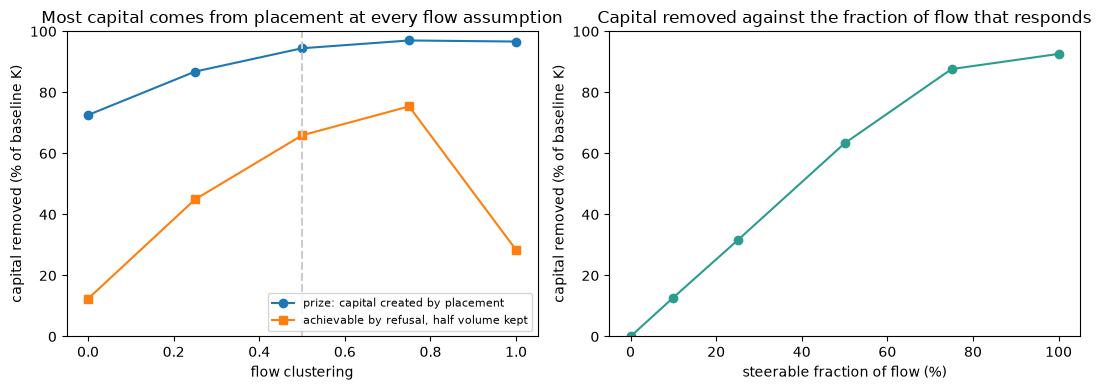

clustering,baseline K ($),baseline R,prize (capital from placement),refusal capital removed,refusal R gain,revenue R gain
0.00,"$12,731",0.0862,72.6%,12.4%,+9.8%,+38.9%
0.25,"$29,158",0.0379,86.8%,44.9%,+60.6%,+68.8%
0.50,"$67,932",0.0170,94.5%,65.9%,+114.2%,+130.4%
0.75,"$95,998",0.0114,97.0%,75.4%,+108.1%,+180.8%
1.00,"$121,663",0.0089,96.7%,28.4%,+15.1%,+225.2%


steerable fraction,capital removed,R gain
0%,0.0%,+0.0%
10%,12.8%,+14.8%
25%,31.5%,+48.7%
50%,63.3%,+203.7%
75%,87.6%,+767.7%
100%,92.6%,+1490.9%


In [4]:
"""Part 4 — sensitivity to the flow assumption, and how much steering is needed."""

CLUSTERING_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
STEER_GRID = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
SWEEP_SEEDS = 8

sweep_rows = []
for clustering in CLUSTERING_GRID:
    base_r, base_k, prizes, refusals, refusal_gains, revenue_gains = [], [], [], [], [], []
    for seed in range(SWEEP_SEEDS):
        flow = draw_flow(TRADES_PER_MARKET, clustering, np.random.default_rng(1_000 + seed))
        outcomes, _ = channels(flow, 1_000 + seed)
        base = outcomes["baseline"]
        base_r.append(base["R"])
        base_k.append(base["K ($)"])
        prizes.append(1.0 - outcomes["full relocation"]["K ($)"] / base["K ($)"])
        refusals.append(1.0 - outcomes["refusal, keep >=50% volume"]["K ($)"] / base["K ($)"])
        refusal_gains.append(outcomes["refusal, keep >=50% volume"]["R"] / base["R"] - 1.0)
        revenue_gains.append(outcomes["revenue only"]["R"] / base["R"] - 1.0)
    sweep_rows.append({
        "clustering": clustering,
        "baseline K ($)": float(np.mean(base_k)),
        "baseline R": float(np.mean(base_r)),
        "prize (capital from placement)": float(np.mean(prizes)),
        "refusal capital removed": float(np.mean(refusals)),
        "refusal R gain": float(np.mean(refusal_gains)),
        "revenue R gain": float(np.mean(revenue_gains)),
    })
sweep = pd.DataFrame(sweep_rows)

steer_rows = []
for steer in STEER_GRID:
    removed, gains = [], []
    for seed in range(SWEEP_SEEDS):
        flow = draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING,
                         np.random.default_rng(2_000 + seed))
        base = simulate(flow, seed=2_000 + seed)
        out = simulate(flow, steer=steer, seed=2_000 + seed)
        removed.append(1.0 - out["K ($)"] / base["K ($)"])
        gains.append(out["R"] / base["R"] - 1.0)
    steer_rows.append({
        "steerable fraction": steer,
        "capital removed": float(np.mean(removed)),
        "R gain": float(np.mean(gains)),
    })
steering = pd.DataFrame(steer_rows)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(sweep["clustering"], sweep["prize (capital from placement)"] * 100,
          marker="o", label="prize: capital created by placement")
left.plot(sweep["clustering"], sweep["refusal capital removed"] * 100,
          marker="s", label="achievable by refusal, half volume kept")
left.axvline(CENTRAL_CLUSTERING, color="#cccccc", linestyle="--")
left.set(title="Most capital comes from placement at every flow assumption",
         xlabel="flow clustering", ylabel="capital removed (% of baseline K)", ylim=(0, 100))
left.legend(loc="lower right", fontsize=8)

right.plot(steering["steerable fraction"] * 100, steering["capital removed"] * 100,
           marker="o", color="#2a9d8f")
right.set(title="Capital removed against the fraction of flow that responds",
          xlabel="steerable fraction of flow (%)",
          ylabel="capital removed (% of baseline K)", ylim=(0, 100))

plt.tight_layout()
plt.show()

display(sweep.style.format({
    "clustering": "{:.2f}",
    "baseline K ($)": "${:,.0f}",
    "baseline R": "{:.4f}",
    "prize (capital from placement)": "{:.1%}",
    "refusal capital removed": "{:.1%}",
    "refusal R gain": "{:+.1%}",
    "revenue R gain": "{:+.1%}",
}).hide(axis="index").set_caption("Prize and achievable channel against the flow assumption"))

display(steering.style.format({
    "steerable fraction": "{:.0%}",
    "capital removed": "{:.1%}",
    "R gain": "{:+.1%}",
}).hide(axis="index").set_caption("How much trader response is needed to capture the prize"))

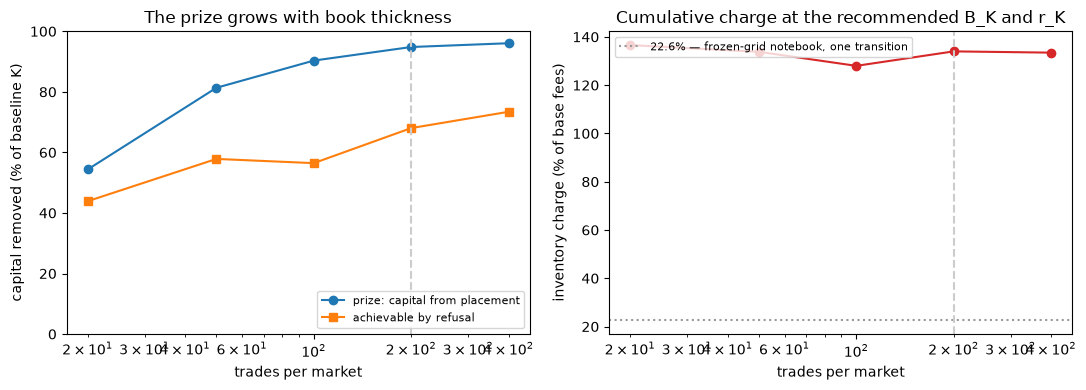

trades,line covers sold,baseline K ($),prize,refusal capital removed,charge / base fees
20,1.2,"$7,167",54.4%,43.9%,137%
50,3.3,"$17,512",81.4%,57.9%,134%
100,6.5,"$31,594",90.3%,56.5%,128%
200,13.1,"$69,374",94.8%,68.0%,134%
400,26.2,"$137,877",96.1%,73.4%,133%


In [5]:
"""Part 5 — book thickness, the largest unswept assumption.

The prize depends on how much payout mass the book sells relative to the
settlement line. At 200 trades averaging 6.4% of probability mass the book
carries roughly thirteen line-covers, which is what lets a perfect allocator
tile it nearly flat. A thin one-minute book cannot be tiled that way, so the
prize and the aggregate charge must both be checked against thickness.
"""

THICKNESS_GRID = [20, 50, 100, 200, 400]

thickness_rows = []
for n_trades in THICKNESS_GRID:
    covers, ks, prizes, refusals, charges = [], [], [], [], []
    for seed in range(SWEEP_SEEDS):
        flow = draw_flow(n_trades, CENTRAL_CLUSTERING, np.random.default_rng(3_000 + seed))
        base = simulate(flow, seed=3_000 + seed)
        perfect = simulate(flow, steer=1.0, seed=3_000 + seed)
        charged = simulate(flow, charge=True, seed=3_000 + seed)
        frontier = [(h, simulate(flow, hurdle=h, seed=3_000 + seed)) for h in HURDLES]
        retained = [
            (h, out) for h, out in frontier
            if np.isfinite(out["R"])
            and out["volume ($)"] >= MIN_VOLUME_KEPT * base["volume ($)"]
        ]
        _, shippable = max(retained, key=lambda pair: pair[1]["R"])

        covers.append(sum(trade.mass for trade in flow))
        ks.append(base["K ($)"])
        prizes.append(1.0 - perfect["K ($)"] / base["K ($)"])
        refusals.append(1.0 - shippable["K ($)"] / base["K ($)"])
        charges.append(charged["inventory income ($)"] / base["income ($)"])
    thickness_rows.append({
        "trades": n_trades,
        "line covers sold": float(np.mean(covers)),
        "baseline K ($)": float(np.mean(ks)),
        "prize": float(np.mean(prizes)),
        "refusal capital removed": float(np.mean(refusals)),
        "charge / base fees": float(np.mean(charges)),
    })
thickness = pd.DataFrame(thickness_rows)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(thickness["trades"], thickness["prize"] * 100, marker="o",
          label="prize: capital from placement")
left.plot(thickness["trades"], thickness["refusal capital removed"] * 100, marker="s",
          label="achievable by refusal")
left.axvline(TRADES_PER_MARKET, color="#cccccc", linestyle="--")
left.set(title="The prize grows with book thickness", xlabel="trades per market",
         ylabel="capital removed (% of baseline K)", xscale="log", ylim=(0, 100))
left.legend(loc="lower right", fontsize=8)

right.plot(thickness["trades"], thickness["charge / base fees"] * 100, marker="o",
           color="#d62828")
right.axhline(22.6, color="#999999", linestyle=":",
              label="22.6% — frozen-grid notebook, one transition")
right.axvline(TRADES_PER_MARKET, color="#cccccc", linestyle="--")
right.set(title="Cumulative charge at the recommended B_K and r_K",
          xlabel="trades per market", ylabel="inventory charge (% of base fees)",
          xscale="log")
right.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

display(thickness.style.format({
    "line covers sold": "{:.1f}",
    "baseline K ($)": "${:,.0f}",
    "prize": "{:.1%}",
    "refusal capital removed": "{:.1%}",
    "charge / base fees": "{:.0%}",
}).hide(axis="index").set_caption("Prize and charge size against book thickness"))

In [6]:
"""Part 6 — apply the decision rule."""


def threshold_verdict(gain: float) -> str:
    if gain < 0.15:
        return ("STOP. No coordinate choice or calibration can make the mechanism worth its "
                "complexity.")
    if gain < 0.50:
        return ("BUILD THE COORDINATE COMPARISON. Shipping depends on how much of the prize a "
                "cheap coordinate captures.")
    return ("PROCEED. The mechanism is worth having; the open question is which estimator is "
            "cheapest, not whether to build one.")


# The pre-registered metric is reported for the record and then set aside: it is
# unbounded under full relocation, so it cannot discriminate between a good
# mechanism and a degenerate counterfactual.
print(f"Pre-registered metric (combined R gain): {combined_r_gain:+.1%}  "
      f"-> {threshold_verdict(combined_r_gain)}")
print("  Set aside: unbounded by construction. Decision taken on the two bounded readings "
      "below.")
print()

# Conservative reading: only channels that need no trader elasticity.
achievable = max(revenue_r_gain, refusal_r_gain)
print(f"CONSERVATIVE READING — elasticity-free channels only")
print(f"  revenue only:                  {revenue_r_gain:+.1%} R gain, 0% capital removed")
print(f"  refusal, {refusal_volume:.0%} of volume kept:  {refusal_r_gain:+.1%} R gain, "
      f"{refusal_capital:.1%} capital removed")
print(f"  -> {threshold_verdict(achievable)}")
print()

steer_for_half = steering.loc[steering["capital removed"] >= 0.5 * prize, "steerable fraction"]
needed = float(steer_for_half.iloc[0]) if len(steer_for_half) else float("nan")
print(f"PRIZE READING — capital created by placement rather than volume")
print(f"  prize at central clustering:    {prize:.1%} of baseline capital")
print(f"  prize range over the sweep:     "
      f"{sweep['prize (capital from placement)'].min():.1%} to "
      f"{sweep['prize (capital from placement)'].max():.1%}")
print(f"  steering needed for half of it: {needed:.0%} of flow must respond")
print()

print("SECONDARY RULES")
if revenue_r_gain > 0.80 * achievable and refusal_capital < 0.10 * prize:
    print("  - Revenue dominates the achievable gain and capital barely moves: the mechanism "
          "is functioning as a fee increase, and raising the base fee is the simpler "
          "substitute.")
if refusal_capital >= 0.50 * prize:
    print("  - Refusal alone captures at least half the prize with no elasticity assumption: "
          "an admission cap is the stronger primitive, because it needs no calibration and "
          "cannot be out-run by an edge larger than the rate.")
print()

print("AGGREGATE CHARGE CHECK")
print(f"  At B_K=${B_K:,.0f} and r_K={R_K:.0%} the cumulative charge is "
      f"{inventory_income / base_fee_income:.0%} of base-fee income, against the 22.6% the "
      f"frozen-grid notebook reports for one transition from an empty book. Sizing the ramp "
      f"to a single transition is what produces the gap: K accumulates across a book while "
      f"the reference event does not.")
print(f"  Across book thickness the charge runs "
      f"{thickness['charge / base fees'].min():.0%} to "
      f"{thickness['charge / base fees'].max():.0%} of base fees, so the recommended rate is "
      f"not a 22% surcharge on any book this experiment can construct.")
print()

print("WHAT THIS DOES NOT SETTLE")
print(f"  The prize is measured against a perfect allocator, and even independently placed "
      f"flow shows {sweep.loc[sweep['clustering'] == 0.0, 'prize (capital from placement)'].iloc[0]:.0%} "
      f"of capital attributable to placement. Much of the prize is therefore ordinary "
      f"inefficiency no mechanism can address, which is why the steering frontier and not the "
      f"prize is the achievable read.")
print(f"  Refusal is non-monotone in clustering: it removes "
      f"{sweep.loc[sweep['clustering'] == 0.75, 'refusal capital removed'].iloc[0]:.0%} of "
      f"capital at clustering 0.75 but only "
      f"{sweep.loc[sweep['clustering'] == 1.0, 'refusal capital removed'].iloc[0]:.0%} at 1.0, "
      f"because a book that is entirely one lump offers no good flow to keep. A cap is "
      f"weakest exactly where concentration is worst.")

Pre-registered metric (combined R gain): +1979.1%  -> PROCEED. The mechanism is worth having; the open question is which estimator is cheapest, not whether to build one.
  Set aside: unbounded by construction. Decision taken on the two bounded readings below.

CONSERVATIVE READING — elasticity-free channels only
  revenue only:                  +128.4% R gain, 0% capital removed
  refusal, 75% of volume kept:  +125.5% R gain, 69.1% capital removed
  -> PROCEED. The mechanism is worth having; the open question is which estimator is cheapest, not whether to build one.

PRIZE READING — capital created by placement rather than volume
  prize at central clustering:    94.8% of baseline capital
  prize range over the sweep:     72.6% to 97.0%
  steering needed for half of it: 50% of flow must respond

SECONDARY RULES
  - Refusal alone captures at least half the prize with no elasticity assumption: an admission cap is the stronger primitive, because it needs no calibration and cannot be out-r

# Part 7 — targeting: is the pool's compensation related to the capital a trade consumes?

Parts 3 to 6 all measure levels, and every level is a function of `B_K` and `r_K`. The revenue channel's `R` gain is the clearest case: capital does not move at all under it, so the gain is exactly the fee arriving, and doubling `r_K` doubles the headline. No level can establish that `K` is the right coordinate.

This part measures alignment instead. Walking flow in arrival order, record for each trade the capital it adds to the book, the contract fee it pays today, and the charge it would pay under the mechanism. Then ask how closely each price follows the capital.

Two properties make this the load-bearing reading:

- Rank correlation and the effective rate are invariant to `r_K`, so neither can be improved by recalibration.
- Once `K` exceeds `B_K` the potential is linear, so the charge is `r_K × capital added` exactly. Its alignment is true by construction rather than measured. **The finding is the size of the gap in today's pricing, not the quality of the fix.**

3,200 trades over 16 seeds at clustering 0.5
53.8% of them add capital
  contract fee ($)       rank corr with capital added +0.151   share paid by trades adding none 41.2%
  inventory charge ($)   rank corr with capital added +0.949   share paid by trades adding none 0.0%

Capital added rises 34x from the bottom fifth to the top.
  contract fee ($)       effective rate 2.58% -> 0.80%
  inventory charge ($)   effective rate 1.96% -> 1.99%



wrote ../docs/assets/inventory-impact-targeting.png


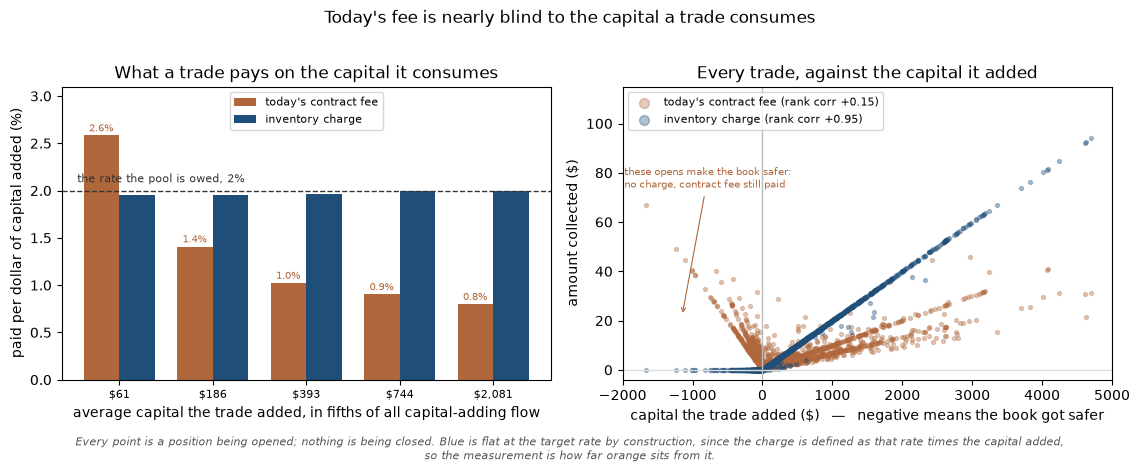

,capital added ($),contract fee ($),inventory charge ($)
quintile,,,
0,$61,2.58%,1.96%
1,$186,1.41%,1.95%
2,$393,1.02%,1.97%
3,$744,0.90%,1.99%
4,"$2,081",0.80%,1.99%


In [7]:
"""Part 7 — per-trade targeting, and the figure shipped with the reference doc."""

from pathlib import Path

QUINTILES = 5
PRICES = ["contract fee ($)", "inventory charge ($)"]
ASSET = Path("../docs/assets/inventory-impact-targeting.png")


def per_trade_ledger(trades) -> pd.DataFrame:
    """Walk flow in arrival order, recording what each trade costs the pool."""
    payout = np.zeros(CELLS)
    capital = 0.0
    rows = []
    for trade in trades:
        payout = payout + payout_profile([trade])
        capital_after = economic_capital(payout)
        rows.append({
            "capital added ($)": capital_after - capital,
            "contract fee ($)": trade.fee,
            # Non-refundable, matching strike_exposure::inventory_impact_charge_for:
            # a trade that lowers capital is free rather than paid.
            "inventory charge ($)": max(0.0, potential(capital_after) - potential(capital)),
        })
        capital = capital_after
    return pd.DataFrame(rows)


ledger = pd.concat(
    per_trade_ledger(draw_flow(TRADES_PER_MARKET, CENTRAL_CLUSTERING,
                               np.random.default_rng(5_000 + seed)))
    for seed in range(SEEDS)
).reset_index(drop=True)


def spearman(a: pd.Series, b: pd.Series) -> float:
    """Rank correlation, so trade size alone cannot inflate the reading."""
    return float(np.corrcoef(a.rank(), b.rank())[0, 1])


alignment = pd.DataFrame([
    {
        "price": price,
        "pearson": float(np.corrcoef(ledger[price], ledger["capital added ($)"])[0, 1]),
        "spearman": spearman(ledger[price], ledger["capital added ($)"]),
    }
    for price in PRICES
])

adds = ledger["capital added ($)"] > 0.0
blind_share = {price: ledger.loc[~adds, price].sum() / ledger[price].sum() for price in PRICES}

# Effective rate paid on the capital each group consumed. A price that tracks
# capital charges every fifth the same rate, and that rate is r_K.
adding = ledger[adds].copy()
adding["quintile"] = pd.qcut(adding["capital added ($)"], QUINTILES, labels=False)
rates = adding.groupby("quintile").apply(
    lambda part: pd.Series({
        "capital added ($)": part["capital added ($)"].mean(),
        **{price: part[price].sum() / part["capital added ($)"].sum() for price in PRICES},
    }),
    include_groups=False,
)

print(f"{len(ledger):,} trades over {SEEDS} seeds at clustering {CENTRAL_CLUSTERING}")
print(f"{adds.mean():.1%} of them add capital")
for price in PRICES:
    print(f"  {price:22} rank corr with capital added {alignment.loc[alignment['price'] == price, 'spearman'].iloc[0]:+.3f}"
          f"   share paid by trades adding none {blind_share[price]:.1%}")
low, high = rates.index.min(), rates.index.max()
print()
print(f"Capital added rises {rates.loc[high, 'capital added ($)'] / rates.loc[low, 'capital added ($)']:.0f}x "
      f"from the bottom fifth to the top.")
for price in PRICES:
    print(f"  {price:22} effective rate {rates.loc[low, price]:.2%} -> {rates.loc[high, price]:.2%}")

FEE_COLOUR, CHARGE_COLOUR = "#b0673b", "#1f4e79"
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

x = np.arange(QUINTILES)
width = 0.38
left.bar(x - width / 2, rates["contract fee ($)"] * 100, width, color=FEE_COLOUR,
         label="today's contract fee")
left.bar(x + width / 2, rates["inventory charge ($)"] * 100, width, color=CHARGE_COLOUR,
         label="inventory charge")
left.axhline(R_K * 100, color="#333333", linestyle="--", linewidth=1)
left.annotate(f"the rate the pool is owed, {R_K:.0%}", xy=(-0.45, R_K * 100), xytext=(0, 6),
              textcoords="offset points", fontsize=8, color="#333333")
for index, value in enumerate(rates["contract fee ($)"]):
    left.annotate(f"{value:.1%}", xy=(index - width / 2, value * 100), xytext=(0, 3),
                  textcoords="offset points", ha="center", fontsize=7.5, color=FEE_COLOUR)
left.set(title="What a trade pays on the capital it consumes",
         xlabel="average capital the trade added, in fifths of all capital-adding flow",
         ylabel="paid per dollar of capital added (%)", ylim=(0, 3.1))
left.set_xticks(x)
left.set_xticklabels([f"${v:,.0f}" for v in rates["capital added ($)"]], fontsize=8)
left.legend(fontsize=8, loc="upper center")

# Clipped to the bulk so the shape stays legible; the right tail runs to $15k.
x_low, x_high = -2_000.0, 5_000.0
shown = ledger[ledger["capital added ($)"].between(x_low, x_high)].sample(2_500, random_state=0)
right.axhline(0, color="#dddddd", linewidth=1)
right.axvline(0, color="#bbbbbb", linewidth=1)
for price, colour in zip(PRICES, (FEE_COLOUR, CHARGE_COLOUR)):
    corr = alignment.loc[alignment["price"] == price, "spearman"].iloc[0]
    label = "today's contract fee" if price == PRICES[0] else "inventory charge"
    right.scatter(shown["capital added ($)"], shown[price], s=8, alpha=0.35, color=colour,
                  label=f"{label} (rank corr {corr:+.2f})")
right.annotate("these opens make the book safer:\nno charge, contract fee still paid",
               xy=(-1_150, 22), xytext=(-1_975, 74), fontsize=7.5, color=FEE_COLOUR,
               arrowprops=dict(arrowstyle="->", color=FEE_COLOUR, lw=0.8))
right.set(title="Every trade, against the capital it added",
          xlabel="capital the trade added ($)   —   negative means the book got safer",
          ylabel="amount collected ($)", xlim=(x_low, x_high), ylim=(-4, 115))
right.legend(fontsize=8, loc="upper left", markerscale=2.5)

fig.suptitle("Today's fee is nearly blind to the capital a trade consumes", fontsize=12, y=1.02)
fig.text(0.5, -0.05,
         "Every point is a position being opened; nothing is being closed. Blue is flat at the "
         "target rate by construction, since the charge is defined as that rate times the "
         "capital added,\nso the measurement is how far orange sits from it.",
         ha="center", fontsize=8, color="#555555", style="italic")
plt.tight_layout()
if ASSET.parent.is_dir():
    plt.savefig(ASSET, dpi=170, bbox_inches="tight")
    print(f"\nwrote {ASSET}")
plt.show()

display(rates.style.format({
    "capital added ($)": "${:,.0f}",
    "contract fee ($)": "{:.2%}",
    "inventory charge ($)": "{:.2%}",
}).set_caption("Effective rate paid on capital consumed, by fifth of capital-adding flow"))

## Part 7, continued — the trade that causes the gap

The aggregate above says the fee and the capital disagree; it does not show what such a trade looks like. This holds a contract completely fixed — same size, same chance of paying, so the fee is identical to the cent — and moves only where it lands.

The book here is small and hand-built so the shapes stay legible. The placement result is not sensitive to that: on books drawn from `draw_flow` at 200 trades, the same $2,900 contract at a 12% chance of paying swings the pool's capital by `+$2,552` at its worst placement against `-$348` at its best, for one unchanged fee of `$18.85`. The swing is the contract's whole notional.

The width half of the story does not survive on a thin book, which is worth knowing before drawing conclusions from small illustrations. When the crowd is narrower than the worst 5% region, a narrow spike already covers the whole tail and widening it adds expected payout faster than tail, so capital *saturates* with width and the wider contract pays the higher rate. That inverts the population regularity measured above, where a broad and diffuse tail makes wider contracts cover more of it.

book capital $3,470; the worst 5% of outcomes pay $2,900 or more
contract: $2,900 at a 12% chance of paying, fee $18.85 at either placement
  on the crowd         capital +2,552   rate paid 0.74%
  away from the crowd  capital -228   frees capital, so no charge


wrote ../docs/assets/inventory-impact-mismatch.png


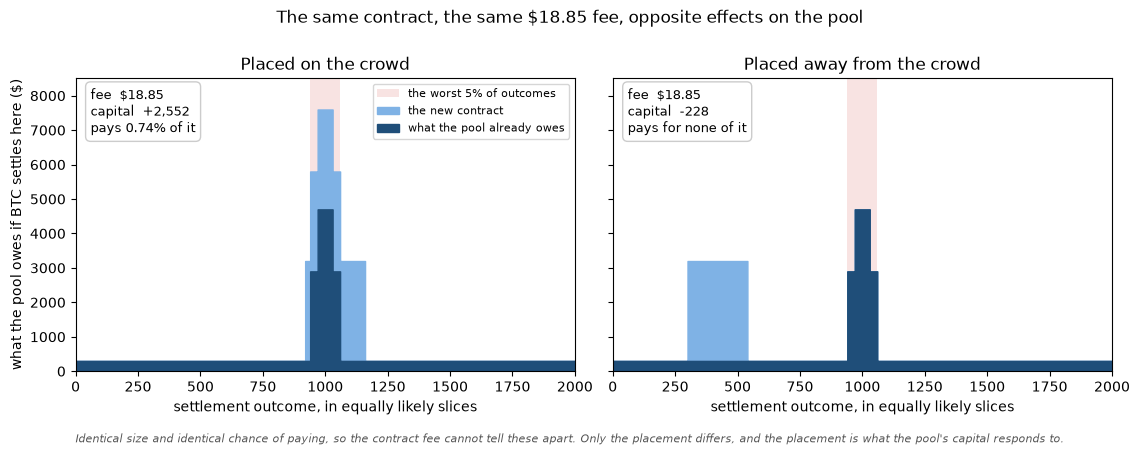

In [8]:
"""Part 7, continued — one contract, two placements, and the doc's worked example."""

MISMATCH_ASSET = Path("../docs/assets/inventory-impact-mismatch.png")

# A legible book: a little owed everywhere, plus a crowd around the middle.
EXAMPLE_BOOK = [Trade(0, CELLS, 300.0), Trade(940, 1_060, 2_600.0), Trade(970, 1_030, 1_800.0)]
CANDIDATE_QUANTITY = 2_900.0
CANDIDATE_WIDTH = 240  # 12% chance of paying

book_payout = payout_profile(EXAMPLE_BOOK)
book_k = economic_capital(book_payout)
tail_cut = np.sort(book_payout)[-TAIL_CELLS]

placements = {}
for label, lower in (("on the crowd", 920), ("away from the crowd", 300)):
    candidate = Trade(lower, lower + CANDIDATE_WIDTH, CANDIDATE_QUANTITY)
    after = book_payout + payout_profile([candidate])
    placements[label] = {
        "trade": candidate,
        "payout": after,
        "capital added": economic_capital(after) - book_k,
        "fee": candidate.fee,
    }

one = placements["on the crowd"]["trade"]
print(f"book capital ${book_k:,.0f}; the worst 5% of outcomes pay ${tail_cut:,.0f} or more")
print(f"contract: ${one.quantity:,.0f} at a {one.mass:.0%} chance of paying, "
      f"fee ${one.fee:.2f} at either placement")
for label, case in placements.items():
    added = case["capital added"]
    tail = "frees capital, so no charge" if added <= 0 else f"rate paid {case['fee'] / added:.2%}"
    print(f"  {label:20} capital {added:+,.0f}   {tail}")

BOOK_COLOUR, ADDED_COLOUR, TAIL_COLOUR = "#1f4e79", "#7fb2e5", "#d9534f"
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
cells = np.arange(CELLS)

in_tail = book_payout >= tail_cut
y_max = max(case["payout"].max() for case in placements.values()) * 1.12

for axis, (label, case) in zip(axes, placements.items()):
    axis.fill_between(cells, 0, y_max, where=in_tail, step="mid", color=TAIL_COLOUR,
                      alpha=0.16, linewidth=0, label="the worst 5% of outcomes")
    axis.fill_between(cells, 0, case["payout"], step="mid", color=ADDED_COLOUR,
                      label="the new contract")
    axis.fill_between(cells, 0, book_payout, step="mid", color=BOOK_COLOUR,
                      label="what the pool already owes")
    added = case["capital added"]
    verdict = ("pays for none of it" if added <= 0
               else f"pays {case['fee'] / added:.2%} of it")
    axis.set(title=f"Placed {label}", xlabel="settlement outcome, in equally likely slices",
             xlim=(0, CELLS), ylim=(0, y_max))
    axis.annotate(f"fee  ${case['fee']:.2f}\ncapital  {added:+,.0f}\n{verdict}",
                  xy=(0.03, 0.97), xycoords="axes fraction", va="top", fontsize=9,
                  bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc"))

axes[0].set_ylabel("what the pool owes if BTC settles here ($)")
axes[0].legend(fontsize=8, loc="upper right")

fig.suptitle(f"The same contract, the same ${one.fee:.2f} fee, opposite effects on the pool",
             fontsize=12, y=1.0)
fig.text(0.5, -0.03,
         "Identical size and identical chance of paying, so the contract fee cannot tell these "
         "apart. Only the placement differs, and the placement is what the pool's capital "
         "responds to.",
         ha="center", fontsize=8, color="#555555", style="italic")
plt.tight_layout()
if MISMATCH_ASSET.parent.is_dir():
    plt.savefig(MISMATCH_ASSET, dpi=170, bbox_inches="tight")
    print(f"wrote {MISMATCH_ASSET}")
plt.show()

# Part 8 — does the stated objective move, and in a way the rate did not decide?

Part 7 shows the pool's compensation is unrelated to the capital a trade consumes. This part shows what that costs in the objective itself, `R = income / capital`.

The rate-independent reading is the *dispersion* of `R` across flow shapes rather than its level. Fee income depends only on each contract's quantity and width, both drawn independently of where trades land, so income is nearly a constant while capital varies by an order of magnitude with concentration. An LP's return per dollar of risk is then decided by where flow happened to go.

`r_K` sets how much of that gap the charge closes, so the residual spread is also a calibration reading: a rate that fully flattened `R` would be the rate that leaves an LP indifferent to flow shape.

As flow concentrates, from evenly spread to entirely piled into one region:


  capital       12,961 -> 122,141  (9.4x)
  income today  1,085 -> 1,148  (1.06x)

R today   spans 10.1x across flow shapes (0.0089 to 0.0897)
R charged spans 4.3x (0.0288 to 0.1244)
Worst flow shape: R rises 3.2x, 0.0089 -> 0.0288

A residual spread means r_K under-compensates concentrated books; see open item P-32.
wrote ../docs/assets/inventory-impact-return.png


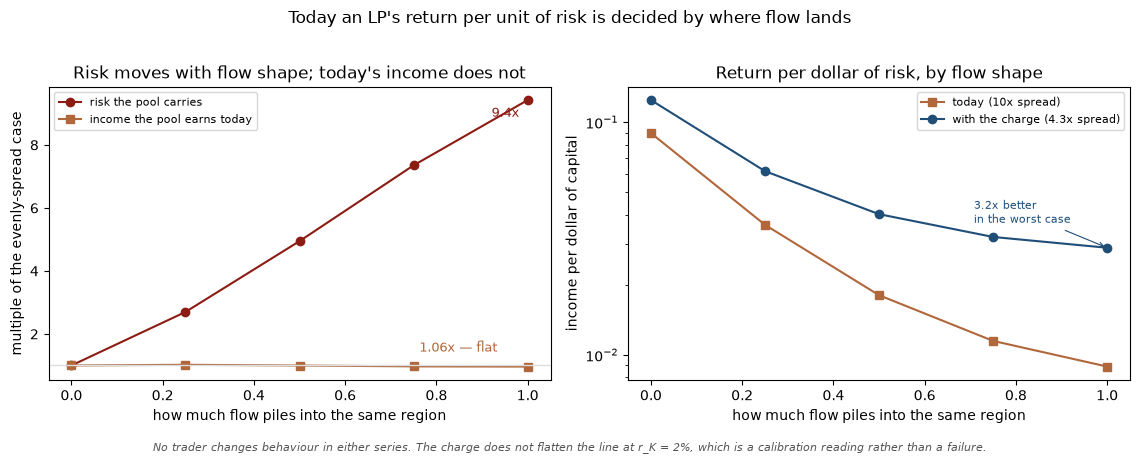

clustering,K ($),income today ($),income charged ($),R today,R charged
0.00,"$12,961","$1,124","$1,568",0.0897,0.1244
0.25,"$34,972","$1,148","$2,016",0.0362,0.0615
0.50,"$64,114","$1,123","$2,537",0.0180,0.0402
0.75,"$95,289","$1,092","$3,057",0.0115,0.0321
1.00,"$122,141","$1,085","$3,520",0.0089,0.0288


In [9]:
"""Part 8 — dispersion of R across flow shapes, and the figure for the reference doc."""

SHAPE_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
SHAPE_SEEDS = 8
RETURN_ASSET = Path("../docs/assets/inventory-impact-return.png")

shape_rows = []
for clustering in SHAPE_GRID:
    today, charged = [], []
    for seed in range(SHAPE_SEEDS):
        flow = draw_flow(TRADES_PER_MARKET, clustering, np.random.default_rng(7_000 + seed))
        today.append(simulate(flow, seed=7_000 + seed))
        charged.append(simulate(flow, charge=True, seed=7_000 + seed))
    today, charged = pd.DataFrame(today), pd.DataFrame(charged)
    shape_rows.append({
        "clustering": clustering,
        "K ($)": today["K ($)"].mean(),
        "income today ($)": today["income ($)"].mean(),
        "income charged ($)": charged["income ($)"].mean(),
        "R today": today["R"].mean(),
        "R charged": charged["R"].mean(),
    })
shapes = pd.DataFrame(shape_rows)


def spread(column: str) -> float:
    return float(shapes[column].max() / shapes[column].min())


print("As flow concentrates, from evenly spread to entirely piled into one region:")
print(f"  capital       {shapes['K ($)'].min():,.0f} -> {shapes['K ($)'].max():,.0f}  "
      f"({spread('K ($)'):.1f}x)")
print(f"  income today  {shapes['income today ($)'].min():,.0f} -> "
      f"{shapes['income today ($)'].max():,.0f}  ({spread('income today ($)'):.2f}x)")
print()
print(f"R today   spans {spread('R today'):.1f}x across flow shapes "
      f"({shapes['R today'].min():.4f} to {shapes['R today'].max():.4f})")
print(f"R charged spans {spread('R charged'):.1f}x "
      f"({shapes['R charged'].min():.4f} to {shapes['R charged'].max():.4f})")
worst = shapes.loc[shapes["clustering"] == max(SHAPE_GRID)].iloc[0]
print(f"Worst flow shape: R rises {worst['R charged'] / worst['R today']:.1f}x, "
      f"{worst['R today']:.4f} -> {worst['R charged']:.4f}")
print()
print("A residual spread means r_K under-compensates concentrated books; see open item P-32.")

TODAY_COLOUR, CHARGED_COLOUR = "#b0673b", "#1f4e79"
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

base = shapes.iloc[0]
left.plot(shapes["clustering"], shapes["K ($)"] / base["K ($)"], marker="o",
          color="#8c1c13", label="risk the pool carries")
left.plot(shapes["clustering"], shapes["income today ($)"] / base["income today ($)"],
          marker="s", color=TODAY_COLOUR, label="income the pool earns today")
left.axhline(1.0, color="#dddddd", linewidth=1)
left.annotate(f"{spread('K ($)'):.1f}x", xy=(1.0, shapes['K ($)'].max() / base['K ($)']),
              xytext=(-26, -12), textcoords="offset points", fontsize=9, color="#8c1c13")
left.annotate(f"{spread('income today ($)'):.2f}x — flat", xy=(1.0, 1.0), xytext=(-78, 10),
              textcoords="offset points", fontsize=9, color=TODAY_COLOUR)
left.set(title="Risk moves with flow shape; today's income does not",
         xlabel="how much flow piles into the same region",
         ylabel="multiple of the evenly-spread case")
left.legend(fontsize=8, loc="upper left")

right.plot(shapes["clustering"], shapes["R today"], marker="s", color=TODAY_COLOUR,
           label=f"today ({spread('R today'):.0f}x spread)")
right.plot(shapes["clustering"], shapes["R charged"], marker="o", color=CHARGED_COLOUR,
           label=f"with the charge ({spread('R charged'):.1f}x spread)")
right.annotate(f"{worst['R charged'] / worst['R today']:.1f}x better\nin the worst case",
               xy=(1.0, worst["R charged"]), xytext=(-96, 18), textcoords="offset points",
               fontsize=8, color=CHARGED_COLOUR,
               arrowprops=dict(arrowstyle="->", color=CHARGED_COLOUR, lw=0.8))
right.set(title="Return per dollar of risk, by flow shape",
          xlabel="how much flow piles into the same region",
          ylabel="income per dollar of capital", yscale="log")
right.legend(fontsize=8, loc="upper right")

fig.suptitle("Today an LP's return per unit of risk is decided by where flow lands",
             fontsize=12, y=1.02)
fig.text(0.5, -0.03,
         "No trader changes behaviour in either series. The charge does not flatten the line "
         f"at r_K = {R_K:.0%}, which is a calibration reading rather than a failure.",
         ha="center", fontsize=8, color="#555555", style="italic")
plt.tight_layout()
if RETURN_ASSET.parent.is_dir():
    plt.savefig(RETURN_ASSET, dpi=170, bbox_inches="tight")
    print(f"wrote {RETURN_ASSET}")
plt.show()

display(shapes.style.format({
    "clustering": "{:.2f}",
    "K ($)": "${:,.0f}",
    "income today ($)": "${:,.0f}",
    "income charged ($)": "${:,.0f}",
    "R today": "{:.4f}",
    "R charged": "{:.4f}",
}).hide(axis="index").set_caption("Objective and its inputs across flow shapes"))

# Part 9 — flat versus convex charging at matched trader cost

This experiment decides whether the capped convex potential earns the stored absolute expected-payout level, scale parameter, and priced refresh walk that a flat charge on marginal centered capital does not need. Both mechanisms use the same 100-bucket range-maximum coordinate, and both retain centering; the flat mechanism consumes `K_after - K_before`, not an uncentered tail level.

Generated books are paired by thickness, clustering, and seed. Convex scales are expressed as multiples of the median final grid capital at 50% clustering for that thickness. For every scale, the flat rate is calibrated to collect the same aggregate inventory income as the convex mechanism across all flow shapes, so the comparison measures allocation of an equal trader charge rather than nominal parameter labels. True 2,000-cell economic capital remains the denominator of risk-adjusted return.

The registered rule is owned by P-32: flat is the default; retain convexity only if the best scale reduces the matched-income cross-shape return spread by at least 25% relative to flat, does not increase the maximum per-trade charge, and does so at the central and adjacent book-thickness settings. A mixed result remains unresolved rather than selecting a mechanism after seeing the run.

MATCHED-INCOME FLAT VS CONVEX
books: 240 paired flows | seeds per shape: 16
flat rate is re-fit at each thickness and convex scale to match aggregate inventory income

UNRESOLVED: convexity materially improves the spread but fails another registered condition; retain the zero rate.
material spread reduction: {100: True, 200: True, 400: True}
full rule passed: {100: False, 200: False, 400: False}


trades,B / central K,B ($),matched flat rate,inventory / ordinary fees,baseline R spread,flat R spread,convex R spread,convex spread reduction vs flat,paired spread reduction mean,paired spread reduction SE,flat clustered R,convex clustered R,flat median charge,convex median charge,flat p95 charge,convex p95 charge,flat max charge,convex max charge,max-charge condition,passes registered rule
100,1.00x,"$36,729",1.144%,85.2%,6.99x,3.77x,2.72x,28.0%,28.0%,0.5%,0.0212,0.0245,$0.79,$0.19,$19.19,$21.30,$99.27,$173.56,False,False
200,1.00x,"$67,758",1.168%,82.8%,10.25x,5.25x,3.81x,27.4%,27.6%,0.3%,0.0213,0.0247,$0.48,$0.06,$20.03,$22.02,$162.45,$278.13,False,False
400,1.00x,"$145,843",1.153%,80.8%,12.61x,6.47x,4.70x,27.4%,27.5%,0.3%,0.0210,0.0244,$0.00,$0.00,$21.14,$23.64,$143.44,$207.19,False,False


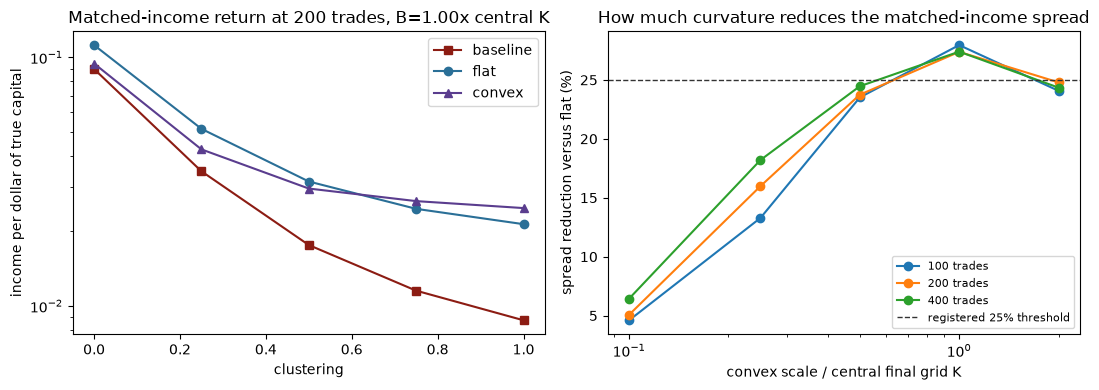

trades,B / central K,B ($),matched flat rate,inventory / ordinary fees,baseline R spread,flat R spread,convex R spread,convex spread reduction vs flat,paired spread reduction mean,paired spread reduction SE,flat clustered R,convex clustered R,flat median charge,convex median charge,flat p95 charge,convex p95 charge,flat max charge,convex max charge,max-charge condition,passes registered rule
100,0.10x,"$3,673",1.905%,141.8%,6.99x,3.13x,2.99x,4.6%,4.5%,0.2%,0.0295,0.0299,$1.31,$1.06,$31.95,$31.80,$165.31,$173.56,False,False
100,0.25x,"$9,182",1.751%,130.4%,6.99x,3.23x,2.80x,13.3%,12.9%,0.6%,0.0278,0.0290,$1.20,$0.68,$29.37,$30.48,$151.96,$173.56,False,False
100,0.50x,"$18,365",1.510%,112.4%,6.99x,3.41x,2.61x,23.5%,23.3%,0.2%,0.0252,0.0275,$1.04,$0.36,$25.32,$27.13,$131.01,$173.56,False,False
100,1.00x,"$36,729",1.144%,85.2%,6.99x,3.77x,2.72x,28.0%,28.0%,0.5%,0.0212,0.0245,$0.79,$0.19,$19.19,$21.30,$99.27,$173.56,False,False
100,2.00x,"$73,458",0.664%,49.5%,6.99x,4.51x,3.42x,24.1%,24.0%,1.1%,0.0160,0.0186,$0.46,$0.10,$11.14,$12.49,$57.64,$158.35,False,False
200,0.10x,"$6,776",1.907%,135.1%,10.25x,4.31x,4.09x,5.1%,5.1%,0.1%,0.0293,0.0297,$0.78,$0.44,$32.70,$33.56,$265.22,$278.13,False,False
200,0.25x,"$16,940",1.749%,123.9%,10.25x,4.46x,3.75x,16.0%,16.0%,0.3%,0.0276,0.0289,$0.72,$0.23,$29.99,$30.76,$243.27,$278.13,False,False
200,0.50x,"$33,879",1.524%,108.0%,10.25x,4.72x,3.60x,23.7%,23.9%,0.2%,0.0251,0.0275,$0.63,$0.12,$26.13,$27.60,$211.94,$278.13,False,False
200,1.00x,"$67,758",1.168%,82.8%,10.25x,5.25x,3.81x,27.4%,27.6%,0.3%,0.0213,0.0247,$0.48,$0.06,$20.03,$22.02,$162.45,$278.13,False,False
200,2.00x,"$135,517",0.692%,49.1%,10.25x,6.35x,4.78x,24.8%,24.8%,0.8%,0.0162,0.0193,$0.28,$0.03,$11.87,$13.11,$96.30,$212.33,False,False


In [10]:
"""Part 9 — matched-income comparison of flat and convex inventory charges."""

GRID_BUCKETS = 100
CELLS_PER_GRID_BUCKET = CELLS // GRID_BUCKETS
GRID_TAIL_BUCKETS = GRID_BUCKETS // 20
assert CELLS_PER_GRID_BUCKET * GRID_BUCKETS == CELLS
assert GRID_TAIL_BUCKETS * 20 == GRID_BUCKETS

COMPARE_THICKNESSES = [100, 200, 400]
COMPARE_CLUSTERING = [0.0, 0.25, 0.5, 0.75, 1.0]
COMPARE_SEEDS = 16
B_MULTIPLIERS = [0.10, 0.25, 0.50, 1.00, 2.00]
CONVEX_MAX_RATE = 0.02


def grid_capital(payout: np.ndarray) -> float:
    """100x1% range-max estimator used by the on-chain coordinate."""
    maxima = payout.reshape(GRID_BUCKETS, CELLS_PER_GRID_BUCKET).max(axis=1)
    cut = GRID_BUCKETS - GRID_TAIL_BUCKETS
    tail = np.partition(maxima, cut)[cut:]
    return float(tail.mean() - payout.mean())


def convex_potential(capital: np.ndarray, scale: float) -> np.ndarray:
    """Capped convex potential evaluated elementwise."""
    capital = np.asarray(capital, dtype=float)
    below = CONVEX_MAX_RATE * capital * capital / (2.0 * scale)
    above = CONVEX_MAX_RATE * scale / 2.0 + CONVEX_MAX_RATE * (capital - scale)
    return np.where(capital <= scale, below, above)


def charge_trace(trades: list[Trade]) -> dict:
    """Walk one generated book once and retain the coordinate path all shapes share."""
    payout = np.zeros(CELLS)
    capital_path = [0.0]
    fees = []
    for trade in trades:
        payout[trade.lower:trade.upper] += trade.quantity
        capital_path.append(grid_capital(payout))
        fees.append(trade.fee)
    capital_path = np.asarray(capital_path)
    return {
        "capital path": capital_path,
        "positive marginal capital": np.maximum(0.0, np.diff(capital_path)),
        "ordinary fees": float(np.sum(fees)),
        "true K": economic_capital(payout),
        "grid K": float(capital_path[-1]),
    }


def paired_flows(n_trades: int, seed: int) -> dict[float, list[Trade]]:
    """Generate all clustering shapes from identical widths, quantities, and placement draws."""
    rng = np.random.default_rng(seed)
    theme = int(rng.integers(0, CELLS))
    widths = np.rint(rng.choice(WIDTH_MASSES, size=n_trades) * CELLS).astype(int)
    quantities = MEDIAN_QUANTITY * np.exp(rng.normal(0.0, QUANTITY_LOG_SD, size=n_trades))
    clustered_draw = np.rint(rng.normal(theme, THEME_SPREAD_CELLS, size=n_trades)).astype(int)
    independent_draw = rng.integers(0, CELLS, size=n_trades)
    cluster_draw = rng.random(n_trades)
    flows = {}
    for clustering in COMPARE_CLUSTERING:
        centers = np.where(cluster_draw < clustering, clustered_draw, independent_draw)
        trades = []
        for width, quantity, center in zip(widths, quantities, centers, strict=True):
            lower = int(np.clip(center - width // 2, 0, CELLS - width))
            trades.append(Trade(lower, lower + int(width), float(quantity)))
        flows[clustering] = trades
    return flows


# Generate every book once. Shapes are paired within each thickness and seed.
traces: dict[tuple[int, float, int], dict] = {}
for thickness in COMPARE_THICKNESSES:
    for seed in range(COMPARE_SEEDS):
        flows = paired_flows(thickness, 80_000 + thickness * 100 + seed)
        for clustering, flow in flows.items():
            traces[(thickness, clustering, seed)] = charge_trace(flow)

central_grid_k = {
    thickness: float(np.median([
        traces[(thickness, 0.5, seed)]["grid K"]
        for seed in range(COMPARE_SEEDS)
    ]))
    for thickness in COMPARE_THICKNESSES
}

comparison_rows = []
per_trade_rows = []
shape_rows = []
for thickness in COMPARE_THICKNESSES:
    thickness_traces = [
        traces[(thickness, clustering, seed)]
        for clustering in COMPARE_CLUSTERING
        for seed in range(COMPARE_SEEDS)
    ]
    flat_units_total = sum(trace["positive marginal capital"].sum() for trace in thickness_traces)

    for b_multiple in B_MULTIPLIERS:
        scale = b_multiple * central_grid_k[thickness]
        convex_charge_vectors = []
        for trace in thickness_traces:
            potentials = convex_potential(trace["capital path"], scale)
            convex_charge_vectors.append(np.maximum(0.0, np.diff(potentials)))
        convex_income_total = sum(charges.sum() for charges in convex_charge_vectors)
        flat_rate = convex_income_total / flat_units_total

        convex_trade_charges = np.concatenate(convex_charge_vectors)
        flat_trade_charges = np.concatenate([
            flat_rate * trace["positive marginal capital"]
            for trace in thickness_traces
        ])

        mechanism_shape_r = {"baseline": [], "flat": [], "convex": []}
        seed_shape_r = {
            mechanism: {seed: [] for seed in range(COMPARE_SEEDS)}
            for mechanism in mechanism_shape_r
        }
        trace_index = 0
        for clustering in COMPARE_CLUSTERING:
            baseline_r, flat_r, convex_r = [], [], []
            for seed in range(COMPARE_SEEDS):
                trace = traces[(thickness, clustering, seed)]
                convex_income = float(convex_charge_vectors[trace_index].sum())
                flat_income = float(flat_rate * trace["positive marginal capital"].sum())
                baseline_r.append(trace["ordinary fees"] / trace["true K"])
                flat_r.append((trace["ordinary fees"] + flat_income) / trace["true K"])
                convex_r.append((trace["ordinary fees"] + convex_income) / trace["true K"])
                trace_index += 1
            for mechanism, values in (
                ("baseline", baseline_r),
                ("flat", flat_r),
                ("convex", convex_r),
            ):
                mean_r = float(np.mean(values))
                mechanism_shape_r[mechanism].append(mean_r)
                for seed, value in enumerate(values):
                    seed_shape_r[mechanism][seed].append(value)
                shape_rows.append({
                    "trades": thickness,
                    "B / central K": b_multiple,
                    "clustering": clustering,
                    "mechanism": mechanism,
                    "R": mean_r,
                })

        spreads = {
            mechanism: max(values) / min(values)
            for mechanism, values in mechanism_shape_r.items()
        }
        paired_spread_reductions = []
        for seed in range(COMPARE_SEEDS):
            flat_seed = seed_shape_r["flat"][seed]
            convex_seed = seed_shape_r["convex"][seed]
            flat_seed_spread = max(flat_seed) / min(flat_seed)
            convex_seed_spread = max(convex_seed) / min(convex_seed)
            paired_spread_reductions.append(1.0 - convex_seed_spread / flat_seed_spread)
        paired_spread_reductions = np.asarray(paired_spread_reductions)
        base_fee_total = sum(trace["ordinary fees"] for trace in thickness_traces)
        comparison_rows.append({
            "trades": thickness,
            "B / central K": b_multiple,
            "B ($)": scale,
            "matched flat rate": flat_rate,
            "inventory / ordinary fees": convex_income_total / base_fee_total,
            "baseline R spread": spreads["baseline"],
            "flat R spread": spreads["flat"],
            "convex R spread": spreads["convex"],
            "convex spread reduction vs flat": 1.0 - spreads["convex"] / spreads["flat"],
            "paired spread reduction mean": float(paired_spread_reductions.mean()),
            "paired spread reduction SE": float(
                paired_spread_reductions.std(ddof=1) / np.sqrt(COMPARE_SEEDS)
            ),
            "flat clustered R": mechanism_shape_r["flat"][-1],
            "convex clustered R": mechanism_shape_r["convex"][-1],
            "flat median charge": float(np.median(flat_trade_charges)),
            "convex median charge": float(np.median(convex_trade_charges)),
            "flat p95 charge": float(np.quantile(flat_trade_charges, 0.95)),
            "convex p95 charge": float(np.quantile(convex_trade_charges, 0.95)),
            "flat max charge": float(flat_trade_charges.max()),
            "convex max charge": float(convex_trade_charges.max()),
        })

comparison = pd.DataFrame(comparison_rows)
shape_comparison = pd.DataFrame(shape_rows)
comparison["max-charge condition"] = comparison["convex max charge"] <= comparison["flat max charge"] + 1e-9
comparison["passes registered rule"] = (
    (comparison["convex spread reduction vs flat"] >= 0.25)
    & comparison["max-charge condition"]
)

best_by_thickness = comparison.loc[
    comparison.groupby("trades")["convex spread reduction vs flat"].idxmax()
].sort_values("trades")
materiality_by_thickness = {
    thickness: bool(
        (comparison.loc[comparison["trades"] == thickness, "convex spread reduction vs flat"] >= 0.25).any()
    )
    for thickness in COMPARE_THICKNESSES
}
qualifying_by_thickness = {
    thickness: bool(comparison.loc[comparison["trades"] == thickness, "passes registered rule"].any())
    for thickness in COMPARE_THICKNESSES
}
if all(qualifying_by_thickness.values()):
    decision = "KEEP CONVEX: it passes the registered materiality and maximum-charge rule at every thickness."
elif not any(materiality_by_thickness.values()):
    decision = "CHOOSE FLAT: convexity misses the registered spread-reduction threshold throughout."
else:
    decision = "UNRESOLVED: convexity materially improves the spread but fails another registered condition; retain the zero rate."

print("MATCHED-INCOME FLAT VS CONVEX")
print(f"books: {len(traces)} paired flows | seeds per shape: {COMPARE_SEEDS}")
print("flat rate is re-fit at each thickness and convex scale to match aggregate inventory income")
print()
print(decision)
print("material spread reduction:", materiality_by_thickness)
print("full rule passed:", qualifying_by_thickness)

display(best_by_thickness.style.format({
    "B / central K": "{:.2f}x",
    "B ($)": "${:,.0f}",
    "matched flat rate": "{:.3%}",
    "inventory / ordinary fees": "{:.1%}",
    "baseline R spread": "{:.2f}x",
    "flat R spread": "{:.2f}x",
    "convex R spread": "{:.2f}x",
    "convex spread reduction vs flat": "{:.1%}",
    "paired spread reduction mean": "{:.1%}",
    "paired spread reduction SE": "{:.1%}",
    "flat clustered R": "{:.4f}",
    "convex clustered R": "{:.4f}",
    "flat median charge": "${:,.2f}",
    "convex median charge": "${:,.2f}",
    "flat p95 charge": "${:,.2f}",
    "convex p95 charge": "${:,.2f}",
    "flat max charge": "${:,.2f}",
    "convex max charge": "${:,.2f}",
}).hide(axis="index").set_caption("Best convex spread reduction at each book thickness"))

central_best = best_by_thickness.loc[best_by_thickness["trades"] == TRADES_PER_MARKET].iloc[0]
central_b = float(central_best["B / central K"])
plot_shapes = shape_comparison.loc[
    (shape_comparison["trades"] == TRADES_PER_MARKET)
    & (shape_comparison["B / central K"] == central_b)
]
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
for mechanism, colour, marker in (
    ("baseline", "#8c1c13", "s"),
    ("flat", "#2a6f97", "o"),
    ("convex", "#5a3d8e", "^"),
):
    frame = plot_shapes.loc[plot_shapes["mechanism"] == mechanism]
    left.plot(frame["clustering"], frame["R"], marker=marker, color=colour, label=mechanism)
left.set(
    title=f"Matched-income return at {TRADES_PER_MARKET} trades, B={central_b:.2f}x central K",
    xlabel="clustering",
    ylabel="income per dollar of true capital",
    yscale="log",
)
left.legend()

for thickness, frame in comparison.groupby("trades"):
    right.plot(
        frame["B / central K"],
        frame["convex spread reduction vs flat"] * 100,
        marker="o",
        label=f"{thickness} trades",
    )
right.axhline(25, color="#333333", linestyle="--", linewidth=1, label="registered 25% threshold")
right.set(
    title="How much curvature reduces the matched-income spread",
    xlabel="convex scale / central final grid K",
    ylabel="spread reduction versus flat (%)",
    xscale="log",
)
right.legend(fontsize=8)
plt.tight_layout()
plt.show()

comparison.sort_values(["trades", "B / central K"]).style.format({
    "B / central K": "{:.2f}x",
    "B ($)": "${:,.0f}",
    "matched flat rate": "{:.3%}",
    "inventory / ordinary fees": "{:.1%}",
    "baseline R spread": "{:.2f}x",
    "flat R spread": "{:.2f}x",
    "convex R spread": "{:.2f}x",
    "convex spread reduction vs flat": "{:.1%}",
    "paired spread reduction mean": "{:.1%}",
    "paired spread reduction SE": "{:.1%}",
    "flat clustered R": "{:.4f}",
    "convex clustered R": "{:.4f}",
    "flat median charge": "${:,.2f}",
    "convex median charge": "${:,.2f}",
    "flat p95 charge": "${:,.2f}",
    "convex p95 charge": "${:,.2f}",
    "flat max charge": "${:,.2f}",
    "convex max charge": "${:,.2f}",
}).hide(axis="index").set_caption("Full matched-income charge-shape sweep")